# Library

In [1]:
import matplotlib
import os

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skbio.diversity import alpha_diversity
from scipy.stats import ranksums, fisher_exact
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_curve, auc

In [3]:
import warnings
# Suppress warnings during the rebuild
warnings.filterwarnings('ignore')
# Rebuild the font cache
import matplotlib.font_manager
matplotlib.font_manager._load_fontmanager(try_read_cache=False)
print("Font cache rebuilt!")

Matplotlib is building the font cache; this may take a moment.


Font cache rebuilt!


In [4]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Set the global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

In [5]:
def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    if x.size != y.size:
        raise ValueError("x and y must be the same size")
    
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    
    ellipse = Ellipse((0, 0),
                      width=ell_radius_x * 2,
                      height=ell_radius_y * 2,
                      facecolor=facecolor,
                      **kwargs)
    
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)
    
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
    
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

def get_significance_label(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

def annotate_within_category_pvalues(ax, long_df, x_col, y_col, hue_col, order, hue_order):
    """
    For each x category (e.g., Bacteria/Fungi/Virus), run Mann–Whitney U between two hue groups (RA vs OA)
    and annotate a bracket + significance label.
    """
    # assumes exactly two groups in hue_order (e.g., ['RA','OA'])
    g1, g2 = hue_order[0], hue_order[1]

    for i, cat in enumerate(order):
        sub = long_df[long_df[x_col] == cat]
        d1 = sub[sub[hue_col] == g1][y_col].dropna()
        d2 = sub[sub[hue_col] == g2][y_col].dropna()

        if len(d1) == 0 or len(d2) == 0:
            sig_label = "na"
            p_value = float("nan")
        else:
            _, p_value = mannwhitneyu(d1, d2, alternative='two-sided')
            sig_label = get_significance_label(p_value)

        # bracket placement
        y_max = sub[y_col].max()
        y = y_max * 1.08
        h = y_max * 0.03 if y_max != 0 else 0.03

        # draw a small bracket centered at category tick
        x_center = i
        x1, x2 = x_center - 0.20, x_center + 0.20
        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c='black')
        ax.text(x_center, y + h, sig_label, ha='center', va='bottom', fontsize=7, color='black')

        # optional: print p-values
        print(f"Mann-Whitney U for {cat}: p = {p_value:.4g}")

# Data

In [ ]:
# Load MaAsLin2 output
bacteria_maaslin2 = pd.read_csv("./99_Original_Data/bacteria_maaslin2_output.tsv", sep='\t')
bacteria_maaslin2 = bacteria_maaslin2[bacteria_maaslin2['metadata'] == 'Responder_Status'].copy()
bacteria_maaslin2['feature'] = bacteria_maaslin2['feature'].str.replace('.', ' ', regex=False)
bacteria_matrix = pd.read_csv("./99_Original_Data/bacteria_final_normalized_count.tsv", sep='\t', index_col=0)  
bacteria_matrix_before_filtering = pd.read_csv("./99_Original_Data/bacteria_unfiltered_count.tsv", sep='\t', index_col=0).transpose()  # Transpose to have samples as rows
metadata = pd.read_csv("./01_Processed_Data/cleaned_metadata.tsv", sep='\t', index_col=1)
ra_metadata = pd.read_csv("./01_Processed_Data/cleaned_metadata_RA.tsv", sep='\t', index_col=0)
metadata['diagnosis'] = metadata['diagnosis'].replace({'Non_RA': 'OA'})
metadata = metadata.merge(ra_metadata['Responder_Status'], left_index=True, right_index=True, how='left')

# Analysis

### Figure 1B

Good - Bacteria: Median = 3.6525, IQR = 0.3719
    IQR Range: 3.5223 - 3.8942
Moderate/No - Bacteria: Median = 3.4846, IQR = 0.5400
    IQR Range: 3.2817 - 3.8217
Mann-Whitney U (Bacteria, Good vs Moderate/No): p = 0.3112
Data shape before plotting: (35, 2)


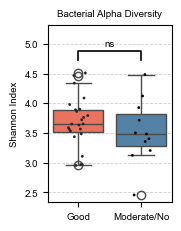

In [9]:
from scipy.stats import mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt

def get_significance_label(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

sample_ids = bacteria_matrix.index
bacterial_counts_for_skbio = bacteria_matrix_before_filtering.astype(int)

bacteria_shannon_div = alpha_diversity(
    metric='shannon',
    counts=bacterial_counts_for_skbio.to_numpy(),
    ids=sample_ids
)
metadata['Bacterial Shannon'] = bacteria_shannon_div

order = ['Good', 'Moderate/No']  # Responder_Status 순서
plot_df = metadata.loc[:, ['Responder_Status', 'Bacterial Shannon']].dropna()
plot_df['Responder_Status'] = plot_df['Responder_Status'].map({'Responder': 'Good', 'Non-Responder': 'Moderate/No'})
for diag in order:
    v = plot_df[plot_df['Responder_Status'] == diag]['Bacterial Shannon'].dropna()
    if len(v) == 0:
        continue
    median_val = v.median()
    q1, q3 = v.quantile(0.25), v.quantile(0.75)
    iqr_val = q3 - q1
    print(f"{diag} - Bacteria: Median = {median_val:.4f}, IQR = {iqr_val:.4f}")
    print(f"    IQR Range: {q1:.4f} - {q3:.4f}")

# ... (Previous code up to step 4 remains the same) ...

# --- 4) Mann-Whitney U (Good vs Moderate/No) ---
d1 = plot_df[plot_df['Responder_Status'] == order[0]]['Bacterial Shannon'].dropna()
d2 = plot_df[plot_df['Responder_Status'] == order[1]]['Bacterial Shannon'].dropna()
_, p_value = mannwhitneyu(d1, d2, alternative='two-sided')
sig_label = get_significance_label(p_value)
print(f"Mann-Whitney U (Bacteria, {order[0]} vs {order[1]}): p = {p_value:.4g}")

# --- 5) Single boxplot: x=Responder_Status ---
fig, ax = plt.subplots(figsize=(1.7, 2.2), constrained_layout=True)

custom_palette = ['#FF6347', '#4682B4']  # Good, Moderate/No 

# 1. Double check your data isn't empty!
print(f"Data shape before plotting: {plot_df.shape}") 

sns.boxplot(
    data=plot_df,
    x='Responder_Status',
    y='Bacterial Shannon',
    hue='Responder_Status',
    palette=custom_palette, 
    order=order,
    hue_order=order,        # <--- ADD THIS LINE
    legend=False,
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x='Responder_Status',
    y='Bacterial Shannon',
    order=order,
    hue='Responder_Status',
    hue_order=order,        # <--- ADD THIS LINE (just to be safe)
    legend=False,
    jitter=0.18,
    size=2,
    color='black',
    ax=ax
)

# dashed horizontal lines
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.xaxis.grid(False)

# ... (The rest of your axis limits and saving logic remains the same) ...

# Significance Bracket
y_max = plot_df['Bacterial Shannon'].max()
y = y_max * 1.05
h = y_max * 0.03 if y_max != 0 else 0.03
x1, x2 = 0, 1

ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c='black')
ax.text((x1 + x2) / 2, y + h + (y_max * 0.01), sig_label, ha='center', va='bottom', fontsize=7, color='black')

# EXPAND Y-AXIS LIMIT so the bracket and text aren't cropped out
ax.set_ylim(bottom=plot_df['Bacterial Shannon'].min() * 0.95, top=y + h + (y_max * 0.1))

ax.set_ylabel('Shannon Index', fontsize=7)
ax.set_xlabel('', fontsize=7)
ax.tick_params(axis='x', labelsize=7)
ax.tick_params(axis='y', labelsize=7)
plt.title('Bacterial Alpha Diversity', fontsize=7)

plt.savefig('./03_Output_Figures/Figure_1B_bacteria.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Figure 1C

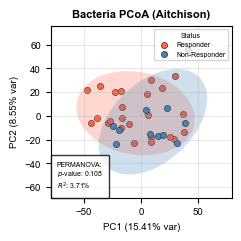

In [10]:
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse
from matplotlib.offsetbox import AnchoredText
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.ordination import pcoa
from skbio.stats.distance import permanova

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# -------------------------------------------------------------------
# 1. 신뢰 타원(Confidence Ellipse) 함수 정의
# -------------------------------------------------------------------
def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    if x.size != y.size:
        raise ValueError("x and y must be the same size")
    
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    
    # Using a special case to obtain the eigenvalues of this 2d covariance matrix
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    
    ellipse = Ellipse((0, 0),
                      width=ell_radius_x * 2,
                      height=ell_radius_y * 2,
                      facecolor=facecolor,
                      **kwargs)
    
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)
    
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
    
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

# -------------------------------------------------------------------
# 2. CLR 변환 함수 정의
# -------------------------------------------------------------------
def clr_transform(X, pseudocount=1e-6):
    """
    Centered log-ratio transform for compositional data (rows = samples).
    """
    X = X.astype(float).clip(lower=0) + pseudocount
    row_sums = X.sum(axis=1).replace(0, np.nan)
    X_rel = X.div(row_sums, axis=0).fillna(pseudocount / X.shape[1])
    logX = np.log(X_rel)
    row_means = logX.mean(axis=1)
    clrX = logX.sub(row_means, axis=0)
    clrX = pd.DataFrame(np.nan_to_num(clrX, nan=0.0, posinf=0.0, neginf=0.0),
                        index=X.index, columns=X.columns)
    clrX = clrX.clip(lower=-50, upper=50)
    return clrX

# -------------------------------------------------------------------
# 3. 데이터 준비 및 전처리
# -------------------------------------------------------------------
# 메타데이터 중복 인덱스 제거
metadata = metadata[~metadata.index.duplicated(keep='first')]


# filter out samples with missing Responder_Status for mat and metadata
metadata_followup = metadata.dropna(subset=['Responder_Status'])

# Bacteria Total-Sum Scaling (Relative Abundance)
mat = bacteria_matrix_before_filtering.div(bacteria_matrix_before_filtering.sum(axis=1), axis=0)
mat_fil = mat.loc[metadata_followup.index.intersection(mat.index)]

# CLR 변환 및 Aitchison Distance (Euclidean) 계산
clr_mat = clr_transform(mat_fil)
aitchison_dist = pdist(clr_mat.values, metric='euclidean')
distance_matrix = DistanceMatrix(squareform(aitchison_dist), ids=clr_mat.index)

# Distance matrix와 metadata 간의 공통 샘플 필터링 (오류 수정 반영)
metadata_followup = metadata[metadata['Responder_Status'] != None]
common_samples = metadata_followup.index.intersection(distance_matrix.ids)
distance_matrix = distance_matrix.filter(common_samples)
metadata_sub = metadata.loc[common_samples]

# -------------------------------------------------------------------
# 4. 통계 및 PCoA 계산
# -------------------------------------------------------------------
# PERMANOVA 실행
permanova_results = permanova(distance_matrix, metadata_sub['Responder_Status'], permutations=9999)

# R² 계산
n = distance_matrix.shape[0]  
g = metadata_sub['Responder_Status'].nunique() 
F_stat = permanova_results['test statistic'] 

if g > 1 and F_stat > 0:
    denominator_term = (n - g) / ((g - 1) * F_stat)
    r2_calculated = (1 / (1 + denominator_term)) * 100 
else:
    r2_calculated = np.nan 

# PCoA 결과 추출
pcoa_results = pcoa(distance_matrix)
pcoa_df = pcoa_results.samples.iloc[:, :2].copy()
pcoa_df.columns = ['PC1', 'PC2']
pcoa_df = pcoa_df.join(metadata_sub)

# -------------------------------------------------------------------
# 5. 시각화 (Scatter + Confidence Ellipse)
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(2.3, 2.3), constrained_layout=True)

group_colors = {
    'Responder': '#FF6347',        # Tomato
    'Non-Responder': '#4682B4'  # SteelBlue
}

for status in pcoa_df['Responder_Status'].dropna().unique():
    group_df = pcoa_df[pcoa_df['Responder_Status'] == status]
    color = group_colors.get(status, 'gray')  # 정의되지 않은 그룹은 gray 처리
    
    # Scatter plot
    sns.scatterplot(
        data=group_df, x='PC1', y='PC2',
        s=20, color=color, alpha=1, ax=ax, edgecolor='k', label=status
    )
    
    # 제공해주신 confidence_ellipse 함수 적용
    if len(group_df) > 2:
        confidence_ellipse(
            group_df['PC1'].values,   # Series 대신 values array 전달이 더 안전함
            group_df['PC2'].values, 
            ax,
            n_std=2,                  # ~95% 신뢰 구간
            facecolor=color, 
            alpha=0.25, 
            edgecolor=color, 
            linewidth=0
        )

# 축 및 레이블 설정
ax.margins(0.2)
ax.set_title('Bacteria PCoA (Aitchison)', fontsize=8, weight='bold')
ax.set_xlabel(f'PC1 ({pcoa_results.proportion_explained[0]*100:.2f}% var)', fontsize=7)
ax.set_ylabel(f'PC2 ({pcoa_results.proportion_explained[1]*100:.2f}% var)', fontsize=7)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', labelsize=7)
ax.tick_params(axis='y', labelsize=7)

# 범례 설정
ax.legend(title="Status", fontsize=5, title_fontsize=5, loc="upper right", frameon=True)

# PERMANOVA 통계량 박스 추가
stats_text = (f"PERMANOVA:\n"
              f"$p$-value: {permanova_results['p-value']:.3g}\n"
              f"$R^2$: {r2_calculated:.2f}%")

at = AnchoredText(stats_text, prop=dict(size=5), frameon=True, loc='lower left')
at.patch.set_boxstyle("round,pad=0.5,rounding_size=0.2")
at.patch.set_alpha(0.8)
ax.add_artist(at)

# PDF 저장 및 출력
plt.savefig('./03_Output_Figures/Figure_1C_Bacteria_Aitchison.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Figure 1D

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from adjustText import adjust_text

def draw_da_volcano_plot(
    maaslin2_df,
    feature_type="Feature",       # 예: "Bacteria", "Virus", "Fungi" -> 제목/파일명에 사용
    group_labels=("Responder", "Non-Responder"),  # (coef > 0 그룹, coef < 0 그룹)
    title=None,
    fc_thresh=1.0,
    q_thresh=0.25,
    top_n_labels=5,
    xlim=None,
    ylim=None,
    save_path=None,
    figsize=(3, 2.3)
):
    # -----------------------------
    # 1. Prepare dataframe
    # -----------------------------
    df = maaslin2_df.copy()

    if "qval" not in df.columns:
        raise ValueError("DA dataframe must contain 'qval' column.")

    df["qval"] = df["qval"].replace(0, np.nextafter(0, 1))
    df["neg_log10_q"] = -np.log10(df["qval"])

    # -----------------------------
    # 2. Determine significance & Direction
    # -----------------------------
    pos_label, neg_label = group_labels
    conditions = [
        (df["qval"] < q_thresh) & (df["coef"] > fc_thresh),
        (df["qval"] < q_thresh) & (df["coef"] < -fc_thresh)
    ]
    choices = [pos_label, neg_label]
    df["Status"] = np.select(conditions, choices, default="Not Significant")

    # -----------------------------
    # 3. Plotting Setup
    # -----------------------------
    if xlim is None:
        xlim = (df["coef"].min() - 0.2, df["coef"].max() + 0.2)
    if ylim is None:
        ylim = (0, df["neg_log10_q"].max() + 0.5)
    if title is None:
        title = f"{group_labels[0]} vs {group_labels[1]}: {feature_type}"
    if save_path is None:
        save_path = f"./03_Output_Figures/Figure_Volcano_{feature_type}.pdf"

    plt.figure(figsize=figsize)

    custom_palette = {
        pos_label: "#FF6347",        # Tomato
        neg_label: "#4682B4",        # SteelBlue
        "Not Significant": "lightgray"
    }
    hue_order = ["Not Significant", pos_label, neg_label]

    # -----------------------------
    # 4. Scatter Plot
    # -----------------------------
    sns.scatterplot(
        data=df,
        x="coef",
        y="neg_log10_q",
        hue="Status",
        hue_order=hue_order,
        palette=custom_palette,
        s=18,
        alpha=1,
        edgecolor="black",
        linewidth=0.5,
        legend="brief"
    )

    # -----------------------------
    # 5. Threshold lines
    # -----------------------------
    plt.axhline(-np.log10(q_thresh), color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    plt.axvline(fc_thresh, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    plt.axvline(-fc_thresh, color="black", linestyle="--", linewidth=0.8, alpha=0.7)

    # -----------------------------
    # 6. Label top significant features
    # -----------------------------
    texts = []
    if "feature" in df.columns:
        sig_df = df[df["Status"] != "Not Significant"]

        if not sig_df.empty:
            top_n = (
                sig_df.groupby("Status", group_keys=False)
                .apply(lambda x: x.nsmallest(top_n_labels, "qval"))
            )

            for _, row in top_n.iterrows():
                texts.append(
                    plt.text(
                        row["coef"],
                        row["neg_log10_q"],
                        str(row["feature"]),
                        fontsize=6,
                        ha="center",
                        va="center",
                        fontstyle="italic"
                    )
                )

            if texts:
                adjust_text(
                    texts,
                    arrowprops=dict(arrowstyle="-", color="black", lw=0.5, alpha=0.6),
                    expand_points=(1.5, 1.5)
                )

    # -----------------------------
    # 7. Final layout
    # -----------------------------
    plt.title(title, fontsize=8, weight="bold")
    plt.xlabel("Effect size (coef)", fontsize=7)
    plt.ylabel(r"$-\log_{10}(q\text{-value})$", fontsize=7)
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid(alpha=0.3, linestyle='--', linewidth=0.5)
    plt.tick_params(axis='x', labelsize=6)
    plt.tick_params(axis='y', labelsize=6)

    plt.legend(title="Associated Group", loc="upper right", bbox_to_anchor=(1.45, 1),
               fontsize=6, title_fontsize=7, frameon=True)

    sns.despine(trim=True)

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    return df  # Status 컬럼 포함된 df 반환 (후속 분석에 유용)

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


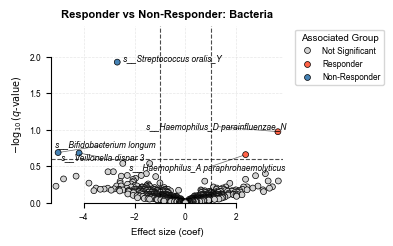

In [11]:
bacteria_status_df = draw_da_volcano_plot(
    bacteria_maaslin2,
    feature_type="Bacteria",
    fc_thresh=1.0,
    q_thresh=0.25,
    top_n_labels=5
)

###

## Figure 1E

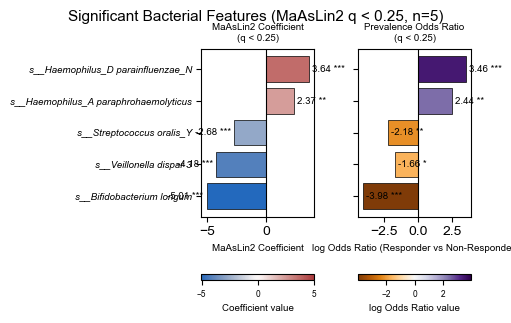

In [12]:
from matplotlib.colors import TwoSlopeNorm
##############################################
# 0. Significant species 선택 (q < 0.25)
##############################################
sig_maaslin = bacteria_maaslin2[bacteria_maaslin2['qval'] < 0.25].sort_values('qval')
sig_species = sig_maaslin['feature'].tolist()

maaslin_coef_map = sig_maaslin.set_index('feature')['coef'].to_dict()
maaslin_pval_map = sig_maaslin.set_index('feature')['pval'].to_dict()

bacteria_matrix.columns = bacteria_matrix.columns.str.replace('.', ' ', regex=False)
merged_bacteria = bacteria_matrix.join(metadata, how='inner')

responder_col = merged_bacteria['Responder_Status']
y_status = responder_col.map({'Non-Responder': 0, 'Responder': 1})
valid_idx = y_status.dropna().index
merged_bacteria = merged_bacteria.loc[valid_idx]
responder_col = responder_col.loc[valid_idx]

species_info_list = [(s, merged_bacteria[s]) for s in sig_species if s in merged_bacteria.columns]

##############################################
# 1. OR / Fisher p-value 계산
##############################################
prevalence_threshold = 1e-6
haldane_correction = 0.5
rows = []

for species_name, abundance in species_info_list:
    group_R  = abundance[responder_col == 'Responder']
    group_NR = abundance[responder_col == 'Non-Responder']

    present_R  = (group_R > prevalence_threshold).sum()
    absent_R   = (group_R <= prevalence_threshold).sum()
    present_NR = (group_NR > prevalence_threshold).sum()
    absent_NR  = (group_NR <= prevalence_threshold).sum()

    a_corr = present_R + haldane_correction
    b_corr = absent_R + haldane_correction
    c_corr = present_NR + haldane_correction
    d_corr = absent_NR + haldane_correction

    odds_ratio = (a_corr * d_corr) / (b_corr * c_corr)
    _, p_logOR = fisher_exact([[present_R, absent_R], [present_NR, absent_NR]])

    rows.append({
        'Species': species_name,
        'Maaslin_Coef': maaslin_coef_map.get(species_name, np.nan),
        'Maaslin_pval': maaslin_pval_map.get(species_name, np.nan),
        'OR': odds_ratio,
        'OR_p': p_logOR
    })

sig_df = pd.DataFrame(rows).set_index('Species')
sig_df['log_OR'] = np.log(sig_df['OR'])

##############################################
# 2. MaAsLin2 coefficient 기준 정렬 (두 plot 공통)
##############################################
sig_df = sig_df.sort_values('Maaslin_Coef', ascending=True)  # barh는 아래→위로 그려지므로 ascending
species_order = sig_df.index.tolist()

def p_to_stars(p):
    if pd.isna(p): return ''
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    return ''

##############################################
# 3. 두 개의 parallel barh plot (색상 = colormap, colorbar = legend)
##############################################
n_species = len(species_order)
height = 0.4 * n_species + 1.0

fig, axes = plt.subplots(1, 2, figsize=(5, height), sharey=True, constrained_layout=True)

# --- Panel 1: MaAsLin2 Coefficient (colormap: vlag, centered at 0) ---
ax1 = axes[0]
coef_vals = sig_df['Maaslin_Coef'].values
coef_absmax = np.abs(coef_vals).max()
norm1 = TwoSlopeNorm(vmin=-coef_absmax, vcenter=0, vmax=coef_absmax)
cmap1 = sns.color_palette("vlag", as_cmap=True)

bars1 = ax1.barh(species_order, coef_vals, color=cmap1(norm1(coef_vals)),
                  edgecolor='black', linewidth=0.5)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_xlabel('MaAsLin2 Coefficient', fontsize=7)
ax1.set_title('MaAsLin2 Coefficient\n(q < 0.25)', fontsize=7)
ax1.set_yticklabels(species_order, style='italic', fontsize=7)

offset1 = 0.03 * (coef_vals.max() - coef_vals.min())
for bar, sp in zip(bars1, species_order):
    stars = p_to_stars(sig_df.loc[sp, 'Maaslin_pval'])
    x = bar.get_width()
    ax1.text(x + offset1 if x >= 0 else x - offset1, bar.get_y() + bar.get_height()/2,
              f"{x:.2f} {stars}", va='center', ha='left' if x >= 0 else 'right', fontsize=7)

sm1 = plt.cm.ScalarMappable(cmap=cmap1, norm=norm1)
sm1.set_array([])
cbar1 = fig.colorbar(sm1, ax=ax1, orientation='horizontal', fraction=0.05, pad=0.12)
cbar1.set_label('Coefficient value', fontsize=7)
cbar1.ax.tick_params(labelsize=6)

# --- Panel 2: Odds Ratio (colormap: PuOr, centered at OR = 1) ---
ax2 = axes[1]
or_vals = sig_df['log_OR'].values
or_dev = np.abs(or_vals).max()  # log-scale symmetric deviation from 1
or_vmin, or_vmax = -or_dev, or_dev
norm2 = TwoSlopeNorm(vmin=or_vmin, vcenter=0, vmax=or_vmax)
cmap2 = sns.color_palette("PuOr", as_cmap=True)

bars2 = ax2.barh(species_order, or_vals, color=cmap2(norm2(or_vals)),
                  edgecolor='black', linewidth=0.5)
ax2.axvline(0, color='black', linewidth=0.8, label='log OR = 0')
ax2.set_xlabel('log Odds Ratio (Responder vs Non-Responder)', fontsize=7)
ax2.set_title('Prevalence Odds Ratio\n(q < 0.25)', fontsize=7)

offset2 = 0.03 * (or_vals.max() - or_vals.min())
for bar, sp in zip(bars2, species_order):
    stars = p_to_stars(sig_df.loc[sp, 'OR_p'])
    x = bar.get_width()
    ax2.text(x + offset2, bar.get_y() + bar.get_height()/2,
              f"{x:.2f} {stars}", va='center', ha='left', fontsize=7)

sm2 = plt.cm.ScalarMappable(cmap=cmap2, norm=norm2)
sm2.set_array([])
cbar2 = fig.colorbar(sm2, ax=ax2, orientation='horizontal', fraction=0.05, pad=0.12)
cbar2.set_label('log Odds Ratio value', fontsize=7)
cbar2.ax.tick_params(labelsize=6)

fig.suptitle(f"Significant Bacterial Features (MaAsLin2 q < 0.25, n={n_species})", fontsize=11, y=1.03)
plt.savefig("./03_Output_Figures/Figure_1E.pdf", dpi=300, bbox_inches='tight')
plt.show()